In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
df = pd.read_excel(r"C:\for_chenna\5th sem\chenna_analytics_project\aldehyde_prj_dataset.xlsx")
df.head()

,Case,Temperature (K),Pressure (Pa),Volume (m3),Feed CH3CHO (mol/s),Product CH3CHO (mol/s),Conversion (%),Heat Load (kW),Residence Time (s),Status,Unnamed: 10,Automation Summary,Unnamed: 12
0,1,940.0,31330,0.90,22.700156,10.326473,54.509244,-244.848493,0.158951,OK,NaN,Total Cases,3000
1,2,940.0,31330,0.92,22.700156,10.177989,55.163355,-247.787257,0.162483,OK,NaN,Temperature Range,940.0 - 960.0 K
2,3,940.0,31330,0.94,22.700156,9.776531,56.931877,-255.732851,0.166015,OK,NaN,Pressure Range,31330.0 - 33330.0 Pa
3,4,940.0,31330,0.96,22.700156,9.632227,57.567576,-258.588926,0.169548,OK,NaN,Volume Range,0.90000000000000002 - 1.1000000000000001 m3
4,5,940.0,31330,0.98,22.700156,9.226590,59.354510,-266.617326,0.173080,OK,NaN,Message,3000-case automation completed


In [2]:
df.drop(columns=['Unnamed: 10','Automation Summary','Unnamed: 12'],inplace=True)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
df.fillna(df.mean(numeric_only=True),inplace=True)
print(df.info())


Rows    : 3000
Columns : 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case                    3000 non-null   int64  
 1   Temperature (K)         3000 non-null   float64
 2   Pressure (Pa)           3000 non-null   int64  
 3   Volume (m3)             3000 non-null   float64
 4   Feed CH3CHO (mol/s)     3000 non-null   float64
 5   Product CH3CHO (mol/s)  3000 non-null   float64
 6   Conversion (%)          3000 non-null   float64
 7   Heat Load (kW)          3000 non-null   float64
 8   Residence Time (s)      3000 non-null   float64
 9   Status                  3000 non-null   object 
dtypes: float64(7), int64(2), object(1)
memory usage: 234.5+ KB
None


In [3]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [4]:
df_num=df.drop(columns=['Case','Status']).copy() #considering only numerical columns which need to be analyzed
df_num.head()

,Temperature (K),Pressure (Pa),Volume (m3),Feed CH3CHO (mol/s),Product CH3CHO (mol/s),Conversion (%),Heat Load (kW),Residence Time (s)
0,940.0,31330,0.90,22.700156,10.326473,54.509244,-244.848493,0.158951
1,940.0,31330,0.92,22.700156,10.177989,55.163355,-247.787257,0.162483
2,940.0,31330,0.94,22.700156,9.776531,56.931877,-255.732851,0.166015
3,940.0,31330,0.96,22.700156,9.632227,57.567576,-258.588926,0.169548
4,940.0,31330,0.98,22.700156,9.226590,59.354510,-266.617326,0.173080


In [5]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature (K),3000.0,941.198800,7.478670e-01,940.000000,940.600000,941.200000,941.800000,942.400000
Pressure (Pa),3000.0,32329.000000,6.051069e+02,31330.000000,31830.000000,32330.000000,32830.000000,33330.000000
Volume (m3),3000.0,0.999920,6.323496e-02,0.900000,0.940000,1.000000,1.060000,1.100000
Feed CH3CHO (mol/s),3000.0,22.700156,7.497476e-13,22.700156,22.700156,22.700156,22.700156,22.700156
Product CH3CHO (mol/s),3000.0,7.923249,1.065591e+00,5.244924,7.095414,7.928431,8.773016,10.326473
Conversion (%),3000.0,65.096058,4.694202e+00,54.509244,61.352618,65.073230,68.742883,76.894766
Heat Load (kW),3000.0,-292.437314,2.177482e+01,-345.689625,-308.921431,-292.371577,-275.678432,0.000000
Residence Time (s),3000.0,0.181997,1.199913e-02,0.158546,0.171972,0.181959,0.191797,0.206676


In [6]:
for col in df_num.columns:
    print(col,":unique values=",df[col].nunique())

Temperature (K) :unique values= 13
Pressure (Pa) :unique values= 21
Volume (m3) :unique values= 11
Feed CH3CHO (mol/s) :unique values= 1
Product CH3CHO (mol/s) :unique values= 2999
Conversion (%) :unique values= 2999
Heat Load (kW) :unique values= 3000
Residence Time (s) :unique values= 3000


In [7]:
for col in df_num.columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) |(df[col] > upper)).sum()
    
    print(col,": outliers=",outliers)

Temperature (K) : outliers= 0
Pressure (Pa) : outliers= 0
Volume (m3) : outliers= 0
Feed CH3CHO (mol/s) : outliers= 0
Product CH3CHO (mol/s) : outliers= 0
Conversion (%) : outliers= 0
Heat Load (kW) : outliers= 1
Residence Time (s) : outliers= 0


In [8]:
df_num.columns = (df_num.columns.str.strip().str.replace(" ", "_"))
print(df_num.columns.tolist())

['Temperature_(K)', 'Pressure_(Pa)', 'Volume_(m3)', 'Feed_CH3CHO_(mol/s)', 'Product_CH3CHO_(mol/s)', 'Conversion_(%)', 'Heat_Load_(kW)', 'Residence_Time_(s)']


In [9]:
df_num.to_excel("acetaldehyde_dataset_cleaned.xlsx",index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [10]:
print(df_num.describe().T)

                         count          mean           std           min  \
Temperature_(K)         3000.0    941.198800  7.478670e-01    940.000000   
Pressure_(Pa)           3000.0  32329.000000  6.051069e+02  31330.000000   
Volume_(m3)             3000.0      0.999920  6.323496e-02      0.900000   
Feed_CH3CHO_(mol/s)     3000.0     22.700156  7.497476e-13     22.700156   
Product_CH3CHO_(mol/s)  3000.0      7.923249  1.065591e+00      5.244924   
Conversion_(%)          3000.0     65.096058  4.694202e+00     54.509244   
Heat_Load_(kW)          3000.0   -292.437314  2.177482e+01   -345.689625   
Residence_Time_(s)      3000.0      0.181997  1.199913e-02      0.158546   

                                 25%           50%           75%           max  
Temperature_(K)           940.600000    941.200000    941.800000    942.400000  
Pressure_(Pa)           31830.000000  32330.000000  32830.000000  33330.000000  
Volume_(m3)                 0.940000      1.000000      1.060000      1.

In [11]:
op_col=['Temperature_(K)','Pressure_(Pa)','Volume_(m3)','Feed_CH3CHO_(mol/s)'] 
for col in op_col:
    print(f"{col:20s} : {df_num[col].min():.4f} to {df_num[col].max():.4f}")

Temperature_(K)      : 940.0000 to 942.4000
Pressure_(Pa)        : 31330.0000 to 33330.0000
Volume_(m3)          : 0.9000 to 1.1000
Feed_CH3CHO_(mol/s)  : 22.7002 to 22.7002


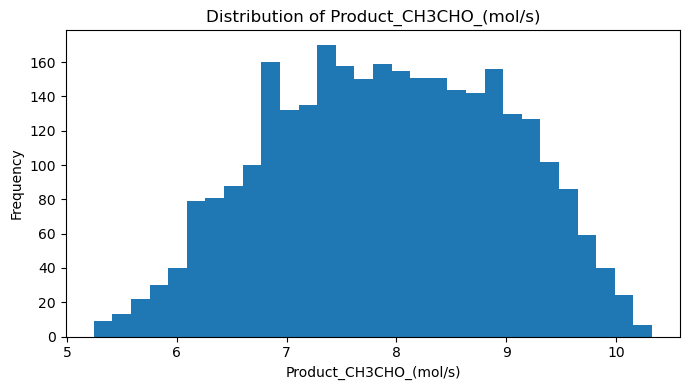

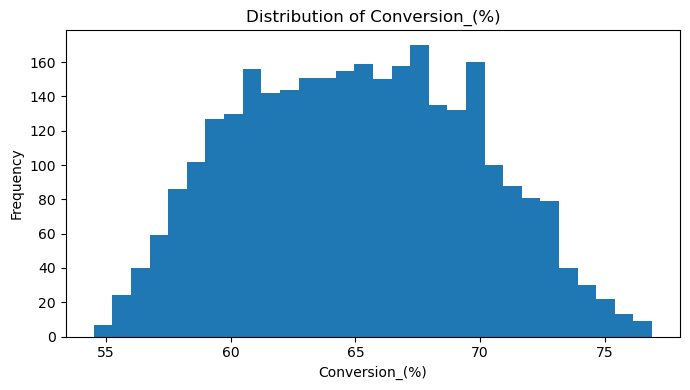

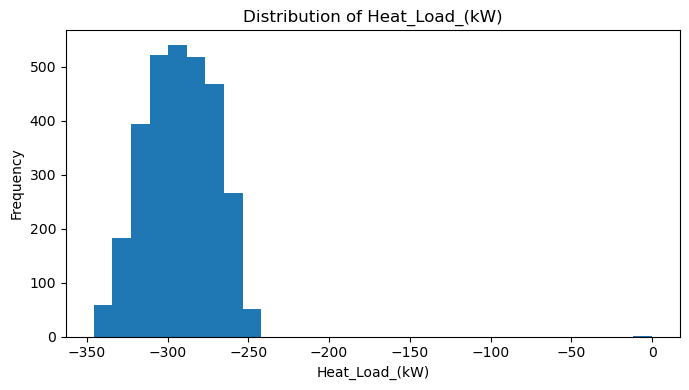

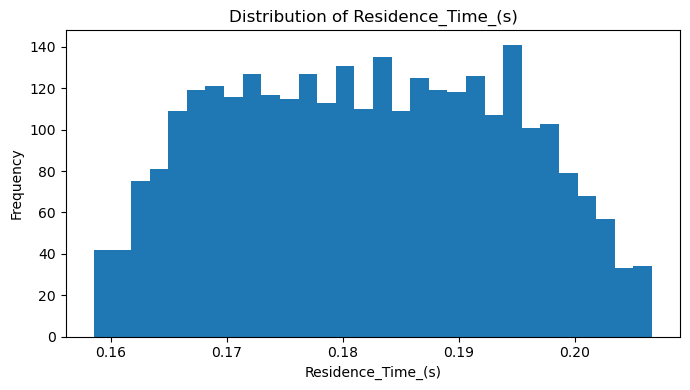

In [12]:

for col in df_num.drop(columns=op_col).columns:
    plt.figure(figsize=(7, 4))
    
    plt.hist(df_num[col], bins=30)
    
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title("Distribution of " + col)
    
    plt.tight_layout()
    plt.show()

In [13]:
correlation = df_num.corr()
correlation

,Temperature_(K),Pressure_(Pa),Volume_(m3),Feed_CH3CHO_(mol/s),Product_CH3CHO_(mol/s),Conversion_(%),Heat_Load_(kW),Residence_Time_(s)
Temperature_(K),1.000000,-0.002655,-0.002033,NaN,-0.235218,0.235218,-0.236658,-0.014824
Pressure_(Pa),-0.002655,1.000000,-0.002094,NaN,-0.386830,0.386830,-0.378062,0.281899
Volume_(m3),-0.002033,-0.002094,1.000000,NaN,-0.887560,0.887560,-0.861292,0.958607
Feed_CH3CHO_(mol/s),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_CH3CHO_(mol/s),-0.235218,-0.386830,-0.887560,NaN,1.000000,-1.000000,0.974798,-0.958719
Conversion_(%),0.235218,0.386830,0.887560,NaN,-1.000000,1.000000,-0.974798,0.958719
Heat_Load_(kW),-0.236658,-0.378062,-0.861292,NaN,0.974798,-0.974798,1.000000,-0.930987
Residence_Time_(s),-0.014824,0.281899,0.958607,NaN,-0.958719,0.958719,-0.930987,1.000000


In [14]:
conversion_corr = df_num.corr()["Heat_Load_(kW)"].sort_values(ascending=False)
conversion_corr=conversion_corr.drop(['Feed_CH3CHO_(mol/s)','Heat_Load_(kW)'])
conversion_corr

Product_CH3CHO_(mol/s)    0.974798
Temperature_(K)          -0.236658
Pressure_(Pa)            -0.378062
Volume_(m3)              -0.861292
Residence_Time_(s)       -0.930987
Conversion_(%)           -0.974798
Name: Heat_Load_(kW), dtype: float64

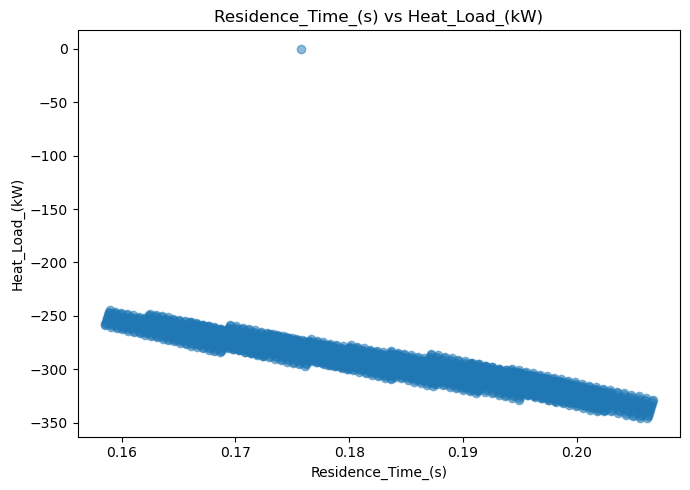

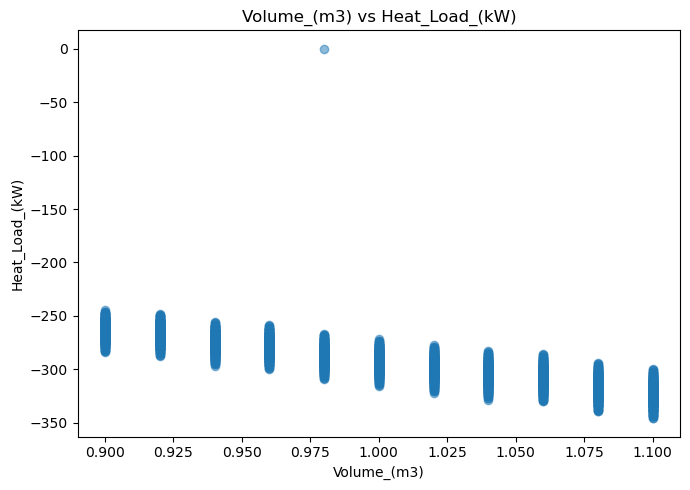

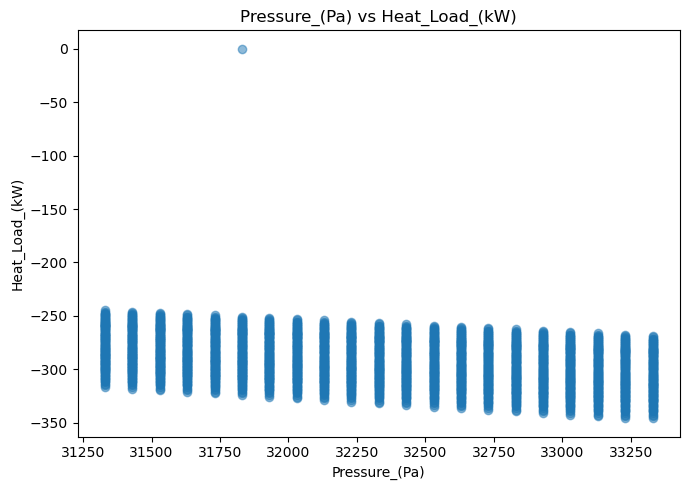

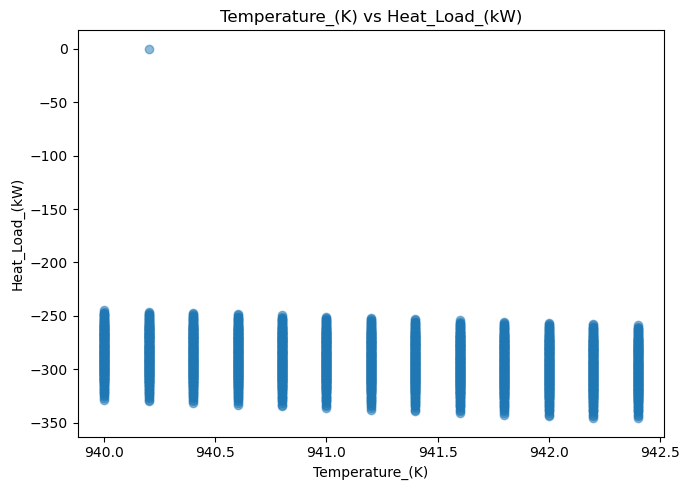

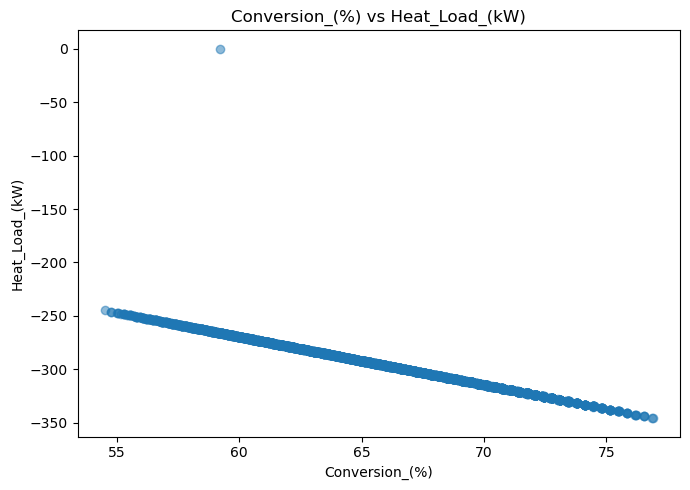

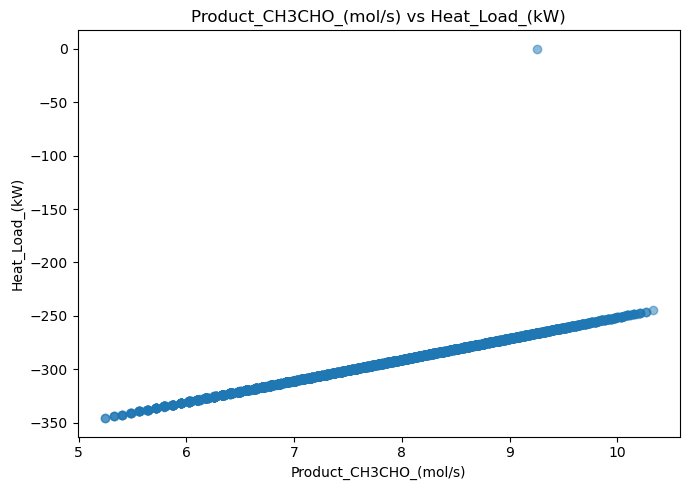

In [15]:
input_columns = [
    "Residence_Time_(s)",
    "Volume_(m3)",
    "Pressure_(Pa)",
    "Temperature_(K)",
    "Conversion_(%)",        
    "Product_CH3CHO_(mol/s)"  
]

for col in input_columns:
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(df_num[col],df_num["Heat_Load_(kW)"],alpha=0.5)
    
    plt.xlabel(col)
    plt.ylabel("Heat_Load_(kW)")
    plt.title( col + " vs Heat_Load_(kW)")
    
    plt.tight_layout()
    plt.show()

In [16]:
# Define ML features and target

features = [
    "Residence_Time_(s)",
    "Volume_(m3)",
    "Pressure_(Pa)",
    "Temperature_(K)",
    "Conversion_(%)",        
]
target = "Heat_Load_(kW)"
X = df_num[features].copy()
y = df_num[target].copy()

print("Input features:")
print(features)

print("\nTarget:",target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Input features:
['Residence_Time_(s)', 'Volume_(m3)', 'Pressure_(Pa)', 'Temperature_(K)', 'Conversion_(%)']

Target: Heat_Load_(kW)

X shape: (3000, 5)
y shape: (3000,)


In [17]:
# Check feature scales

scale_check = X.describe().T[ ["min", "max", "mean", "std"] ]

print(scale_check)

                             min           max          mean         std
Residence_Time_(s)      0.158546      0.206676      0.181997    0.011999
Volume_(m3)             0.900000      1.100000      0.999920    0.063235
Pressure_(Pa)       31330.000000  33330.000000  32329.000000  605.106920
Temperature_(K)       940.000000    942.400000    941.198800    0.747867
Conversion_(%)         54.509244     76.894766     65.096058    4.694202


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining percentage:", X_train.shape[0] / len(X) * 100)
print("Testing percentage :", X_test.shape[0] / len(X) * 100)

Training samples: 2400
Testing samples : 600

Training percentage: 80.0
Testing percentage : 20.0


In [19]:


scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Original training data:")
print(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:
      Residence_Time_(s)  Volume_(m3)  Pressure_(Pa)  Temperature_(K)  \
642             0.181842         0.98          32930            940.4   
700             0.183559         1.04          31330            940.6   
226             0.191645         1.02          33330            940.0   
1697            0.173078         0.96          32030            941.4   
1010            0.194837         1.08          32030            940.8   

      Conversion_(%)  
642        64.550270  
700        63.863487  
226        67.786428  
1697       61.452821  
1010       68.863765  

Scaled training data:
[[-0.01172031 -0.3185531   1.00892588 -1.09045269 -0.11847837]
 [ 0.13193699  0.62959998 -1.63635296 -0.82211613 -0.26603756]
 [ 0.80832698  0.31354896  1.67024559 -1.6271258   0.57682824]
 [-0.74486474 -0.63460412 -0.47904346  0.2512301  -0.78398236]
 [ 1.07536527  1.26170204 -0.47904346 -0.55377957  0.80830001]]


In [20]:
scaled_check = pd.DataFrame(X_train_scaled,columns=features)

print(scaled_check.describe().T[["mean", "std", "min", "max"]])

                            mean       std       min       max
Residence_Time_(s) -1.415164e-15  1.000208 -1.960547  2.065728
Volume_(m3)        -2.084259e-15  1.000208 -1.582757  1.577753
Pressure_(Pa)       1.184238e-17  1.000208 -1.636353  1.670246
Temperature_(K)    -1.389081e-13  1.000208 -1.627126  1.592913
Conversion_(%)     -2.546111e-15  1.000208 -2.219728  2.532631


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

In [22]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [23]:
results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print(results_df.round(4))

Training Linear Regression...
Training XGBoost...
Training KNN...

MODEL COMPARISON
               Model  Train R2  Test R2  Train MAE  Test MAE  Train RMSE  \
0  Linear Regression    0.9386   0.9992     0.6000    0.4884      5.3933   
1            XGBoost    1.0000   0.9974     0.0588    0.1946      0.0805   
2                KNN    0.9579   0.9993     0.3618    0.3807      4.4675   

   Test RMSE  
0     0.6227  
1     1.1160  
2     0.5776  


In [24]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ])
}

In [25]:
cv_results = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores["test_R2"].mean(),
        "CV R2 Std": scores["test_R2"].std(),
        "CV MAE Mean": -scores["test_MAE"].mean(),
        "CV RMSE Mean": -scores["test_RMSE"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(5))

,Model,CV R2 Mean,CV R2 Std,CV MAE Mean,CV RMSE Mean
0,Linear Regression,0.94994,0.09731,0.60193,3.05573
1,XGBoost,0.94085,0.09290,0.34172,4.25984
2,KNN,0.94172,0.10024,0.68624,3.65393


In [26]:
predictions = {}

for name, model in cv_models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)

print("Predictions generated for all 3 models.")

Predictions generated for all 3 models.


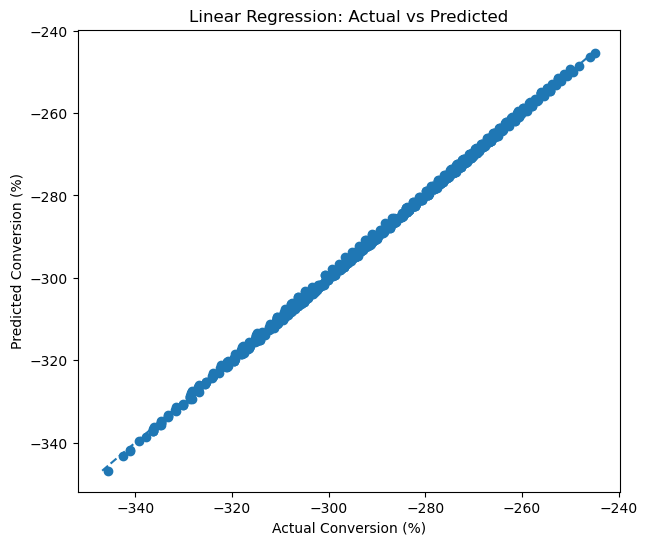

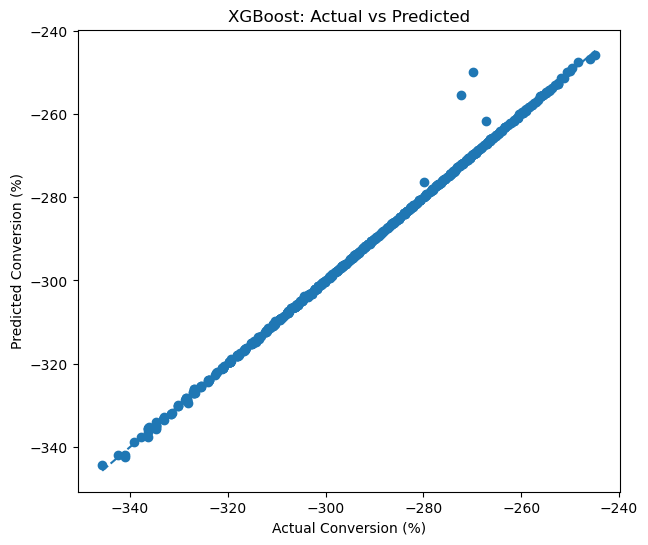

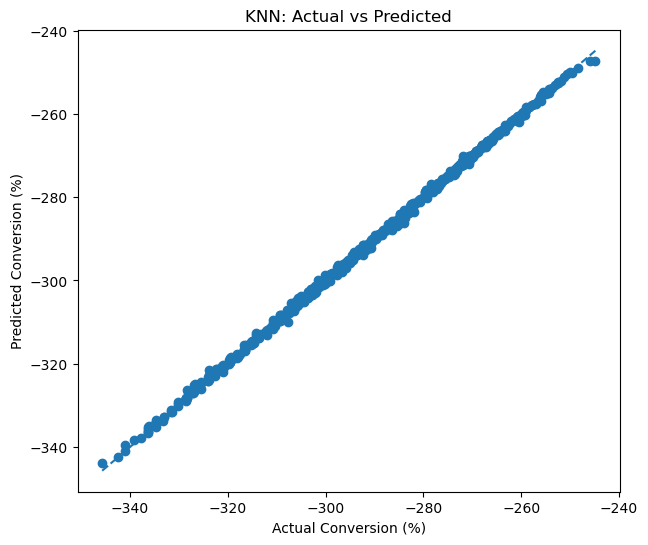

In [27]:
import matplotlib.pyplot as plt

for name, y_pred in predictions.items():

    plt.figure(figsize=(7, 6))

    plt.scatter(y_test, y_pred)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val],[min_val, max_val],linestyle="--")

    plt.xlabel("Actual Conversion (%)")
    plt.ylabel("Predicted Conversion (%)")
    plt.title(f"{name}: Actual vs Predicted")

    plt.show()

In [28]:
residuals = {}

for name, y_pred in predictions.items():
    residuals[name] = y_test.values - y_pred

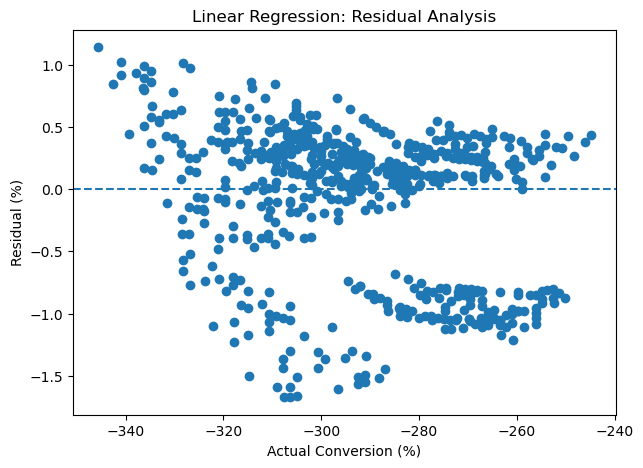

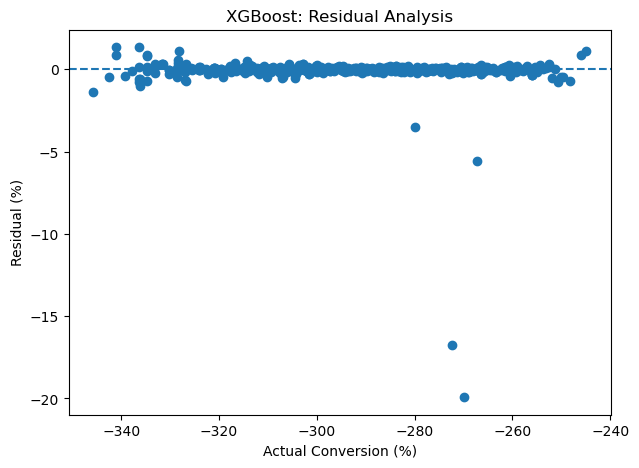

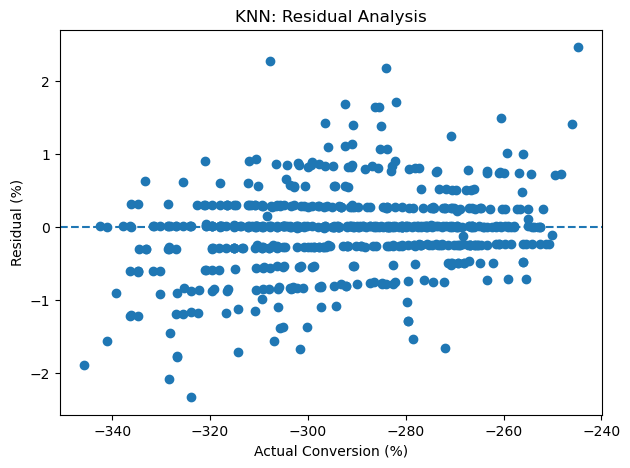

In [29]:
for name, residual in residuals.items():

    plt.figure(figsize=(7, 5))

    plt.scatter(y_test, residual)

    plt.axhline(y=0,linestyle="--")

    plt.xlabel("Actual Conversion (%)")
    plt.ylabel("Residual (%)")
    plt.title(f"{name}: Residual Analysis")

    plt.show()

In [33]:

# LINEAR REGRESSION COEFFICIENT ANALYSIS
# Get the Linear Regression pipeline
linear_pipeline = cv_models["Linear Regression"]

# Fit the pipeline on the training data
linear_pipeline.fit(X_train, y_train)

# Extract scaler and Linear Regression model
linear_scaler = linear_pipeline.named_steps["scaler"]
linear_model = linear_pipeline.named_steps["model"]

# Standardized coefficients
standardized_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

standardized_coefficients["Absolute_Importance"] = (
    standardized_coefficients["Coefficient"].abs()
)

standardized_coefficients = standardized_coefficients.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("STANDARDIZED FEATURE COEFFICIENTS")
display(standardized_coefficients.round(6))

# Original-unit coefficients

original_coefficients = linear_model.coef_ / linear_scaler.scale_

original_coefficients_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": original_coefficients
})

original_coefficients_df["Absolute_Importance"] = (
    original_coefficients_df["Coefficient"].abs()
)

original_coefficients_df = original_coefficients_df.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("\nORIGINAL-UNIT FEATURE COEFFICIENTS")
display(original_coefficients_df.round(6))
# Intercept

print(f"\nLinear Regression Intercept:{linear_model.intercept_:.6f}")

STANDARDIZED FEATURE COEFFICIENTS


,Feature,Coefficient,Absolute_Importance
4,Conversion_(%),-30.331026,30.331026
0,Residence_Time_(s),13.908462,13.908462
1,Volume_(m3),-4.998955,4.998955
3,Temperature_(K),2.192995,2.192995
2,Pressure_(Pa),-0.357845,0.357845



ORIGINAL-UNIT FEATURE COEFFICIENTS


,Feature,Coefficient,Absolute_Importance
0,Residence_Time_(s),1163.498372,1163.498372
1,Volume_(m3),-78.996238,78.996238
4,Conversion_(%),-6.516789,6.516789
3,Temperature_(K),2.942304,2.942304
2,Pressure_(Pa),-0.000592,0.000592



Linear Regression Intercept:-292.441823
